# Phase 10 — A/B Comparison Notebook
Compares: Content-only | ALS | MF | NCF | Hybrid
Metrics: Recall@10, Precision@10, NDCG@10
Protocol: seed = last train item | ground truth = test item (leave-one-out)

## Cell 1 — Imports + Working Directory

In [1]:
import os
import sys
import json
import random
import importlib
import contextlib
import io
import numpy as np
import pandas as pd
import torch
import dill
import scipy.sparse as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Working directory and src path ───────────────────────────────────────────
os.chdir(r'E:\rs')
sys.path.insert(0, r'E:\rs\src')

print('Working directory:', os.getcwd())

Working directory: E:\rs


## Cell 2 — create_dirs()

In [2]:
os.makedirs('outputs', exist_ok=True)
print('Output directory ready.')

Output directory ready.


## Cell 3 — Load Data
Load both train_df (seed source) and test_df (ground truth).

In [3]:
# test_df  = ground truth (last interaction per user from Phase 6)
# train_df = seed source  (all prior interactions)
test_df  = pd.read_parquet('data/test_df.parquet')
train_df = pd.read_parquet('data/train_df.parquet')

print('test_df shape: ', test_df.shape)
print('train_df shape:', train_df.shape)

# Build seed lookup: user_id -> last training item (input to recommenders)
seed_lookup = (
    train_df.sort_values('timestamp')
    .groupby('user_id')['item_id']
    .last()
    .to_dict()
)
print(f'Seed lookup: {len(seed_lookup)} users')
print(f'Items per user in test_df: {test_df.groupby("user_id")["item_id"].count().describe()}')

test_df shape:  (12569, 6)
train_df shape: (128009, 6)
Seed lookup: 12569 users
Items per user in test_df: count    12569.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: item_id, dtype: float64


## Cell 4 — Load Models

In [4]:
# ── Hybrid model ──────────────────────────────────────────────────────────────
with open('models/hybrid_recommender.pkl', 'rb') as f:
    hybrid_model = dill.load(f)
print('Hybrid model loaded.')
print('  known_users:', len(hybrid_model._known_users))

# ── ALS ───────────────────────────────────────────────────────────────────────
from implicit.als import AlternatingLeastSquares
als_model = AlternatingLeastSquares()
als_model.load('models/als_model.npz')

# Load factors manually (als_model.load() may not restore them)
npz = np.load('models/als_model.npz', allow_pickle=True)
als_model.user_factors = npz['user_factors']
als_model.item_factors = npz['item_factors']
print(f'ALS loaded. user_factors={als_model.user_factors.shape} item_factors={als_model.item_factors.shape}')

# ── user_item_matrix for ALS recommend() ─────────────────────────────────────
user_item_matrix = sp.load_npz('models/user_item_matrix.npz')
print(f'user_item_matrix: {user_item_matrix.shape}')

# ── Load item and user maps ───────────────────────────────────────────────────
with open('data/item_map.json', 'r') as f:
    item_map = {k: int(v) for k, v in json.load(f).items()}
with open('data/user_map.json', 'r') as f:
    user_map_global = {k: int(v) for k, v in json.load(f).items()}

reverse_item_map = {v: k for k, v in item_map.items()}   # int idx -> ASIN

print(f'item_map: {len(item_map)} items')
print(f'user_map: {len(user_map_global)} users')

Hybrid model loaded.
  known_users: 12568
ALS loaded. user_factors=(12569, 64) item_factors=(44301, 64)
user_item_matrix: (12569, 44301)
item_map: 44301 items
user_map: 12569 users


In [5]:
# ── MF and NCF models ─────────────────────────────────────────────────────────
import importlib
mf_module = importlib.util.spec_from_file_location('mf_ncf', r'E:\rs\src\06_mf_ncf_pytorch.py')
mf_mod    = importlib.util.module_from_spec(mf_module)
mf_module.loader.exec_module(mf_mod)
MF  = mf_mod.MF
NCF = mf_mod.NCF

# Get exact sizes from state dicts
mf_state  = torch.load('models/mf_model.pth',  map_location='cpu')
ncf_state = torch.load('models/ncf_model.pth', map_location='cpu')

mf_n_users  = mf_state['user_emb.weight'].shape[0]
mf_n_items  = mf_state['item_emb.weight'].shape[0]
mf_emb_dim  = mf_state['user_emb.weight'].shape[1]

ncf_n_users = ncf_state['user_emb_gmf.weight'].shape[0]
ncf_n_items = ncf_state['item_emb_gmf.weight'].shape[0]
ncf_emb_dim = ncf_state['user_emb_gmf.weight'].shape[1]

print(f'MF  → n_users={mf_n_users}, n_items={mf_n_items}, emb_dim={mf_emb_dim}')
print(f'NCF → n_users={ncf_n_users}, n_items={ncf_n_items}, emb_dim={ncf_emb_dim}')

mf_model = MF(n_users=mf_n_users, n_items=mf_n_items, emb_dim=mf_emb_dim)
mf_model.load_state_dict(mf_state)
mf_model.eval()
print('MF model loaded.')

ncf_model = NCF(n_users=ncf_n_users, n_items=ncf_n_items, emb_dim=ncf_emb_dim)
ncf_model.load_state_dict(ncf_state)
ncf_model.eval()
print('NCF model loaded.')

Using device: cuda
MF  → n_users=12569, n_items=44301, emb_dim=64
NCF → n_users=12569, n_items=44301, emb_dim=64
MF model loaded.
NCF model loaded.


## Cell 5 — Metrics

In [6]:
def recall_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    return len(set(actual) & set(predicted[:k])) / len(actual)


def precision_at_k(actual, predicted, k=10):
    if not predicted:
        return 0.0
    return len(set(actual) & set(predicted[:k])) / k


def ndcg_at_k(actual, predicted, k=10):
    """Normalised DCG — divided by IDCG, result in [0, 1]."""
    actual_set = set(actual)
    dcg  = sum(1 / np.log2(i + 2) for i, p in enumerate(predicted[:k]) if p in actual_set)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual_set), k)))
    return dcg / idcg if idcg > 0 else 0.0


print('Metric functions defined.')

Metric functions defined.


## Cell 6 — Generic Evaluator
Protocol: seed = last train item (input) | ground truth = test item
This ensures input ≠ ground truth — fixes Recall@10=0 issue.

In [7]:
def evaluate_model(recommender_fn, eval_df, k=10):
    """
    For each user:
      - ground truth = item in test_df (last interaction from Phase 6 split)
      - seed         = last item from train_df (passed as input_item)
    This ensures input != ground truth.
    """
    recalls, precisions, ndcgs = [], [], []

    for user_id, group in tqdm(eval_df.groupby('user_id')):
        # Ground truth = test item
        actual_items = group['item_id'].tolist()

        # Seed = last training item
        input_item = seed_lookup.get(user_id)
        if input_item is None:
            continue

        try:
            preds = recommender_fn(user_id, k, input_item=input_item)
        except Exception:
            continue

        if not preds:
            continue

        recalls.append(recall_at_k(actual_items, preds, k))
        precisions.append(precision_at_k(actual_items, preds, k))
        ndcgs.append(ndcg_at_k(actual_items, preds, k))

    return {
        'recall@10':    np.mean(recalls)    if recalls    else 0.0,
        'precision@10': np.mean(precisions) if precisions else 0.0,
        'ndcg@10':      np.mean(ndcgs)      if ndcgs      else 0.0,
    }


print('Evaluator defined.')

Evaluator defined.


## Section 2 — Content-only Baseline

In [8]:
def content_fn(user_id, k=10, input_item=None):
    """
    Seeds from last training item (input_item).
    Ground truth = test item (handled by evaluator).
    """
    if input_item is None:
        return []
    recs = hybrid_model.product_rec.get_recommendations(input_item, top_n=k)
    return [r['item_id'] for r in recs]


print('Evaluating Content-only...')
content_results = evaluate_model(content_fn, test_df)
print('Content Results:', content_results)

Evaluating Content-only...


100%|██████████| 12569/12569 [02:21<00:00, 88.98it/s]

Content Results: {'recall@10': 0.030710478160553743, 'precision@10': 0.0030710478160553742, 'ndcg@10': 0.014805219252861592}


## Section 3 — ALS-only Baseline

In [9]:
def als_fn(user_id, k=10, input_item=None):
    """
    ALS uses user_item_matrix row for the user.
    input_item not needed — ALS uses full interaction history.
    """
    cf = hybrid_model.cf_rec

    if user_id not in cf.user_map:
        return []

    user_idx   = cf.user_map[user_id]
    user_items = user_item_matrix[user_idx]   # correct matrix from Phase 9

    ids, scores = als_model.recommend(
        user_idx, user_items, N=k, filter_already_liked_items=True
    )

    return [cf.idx_to_item[i] for i in ids.tolist() if i in cf.idx_to_item]


print('Evaluating ALS-only...')
als_results = evaluate_model(als_fn, test_df)
print('ALS Results:', als_results)

Evaluating ALS-only...


100%|██████████| 12569/12569 [00:05<00:00, 2132.52it/s]

ALS Results: {'recall@10': 0.0003978357733927435, 'precision@10': 3.9783577339274344e-05, 'ndcg@10': 0.00022089447541353974}


## Section 4 — MF (Matrix Factorisation)

In [10]:
def mf_fn(user_id, k=10, input_item=None):
    """
    MF scores all sampled items for the user.
    Uses user_map_global (same maps used during training).
    """
    if user_id not in user_map_global:
        return []

    user_idx      = user_map_global[user_id]
    all_items     = list(item_map.values())
    sampled_items = random.sample(all_items, min(500, len(all_items)))

    scores = []
    for item_idx in sampled_items:
        u = torch.tensor([user_idx])
        i = torch.tensor([item_idx])
        with torch.no_grad():
            score = mf_model(u, i).item()
        scores.append((item_idx, score))

    top_items = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
    return [reverse_item_map[i] for i, _ in top_items if i in reverse_item_map]


print('Evaluating MF...')
mf_results = evaluate_model(mf_fn, test_df)
print('MF Results:', mf_results)

Evaluating MF...


100%|██████████| 12569/12569 [06:41<00:00, 31.28it/s]

MF Results: {'recall@10': 0.0032619937942557084, 'precision@10': 0.0003261993794255709, 'ndcg@10': 0.002344434139367235}


## Section 4B — NCF (Neural Collaborative Filtering)

In [11]:
def ncf_fn(user_id, k=10, input_item=None):
    if user_id not in user_map_global:
        return []

    user_idx      = user_map_global[user_id]
    all_items     = list(item_map.values())
    sampled_items = random.sample(all_items, min(500, len(all_items)))

    scores = []
    for item_idx in sampled_items:
        u = torch.tensor([user_idx])
        i = torch.tensor([item_idx])
        with torch.no_grad():
            score = ncf_model(u, i).item()
        scores.append((item_idx, score))

    top_items = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
    return [reverse_item_map[i] for i, _ in top_items if i in reverse_item_map]


print('Evaluating NCF...')
ncf_results = evaluate_model(ncf_fn, test_df)
print('NCF Results:', ncf_results)

Evaluating NCF...


100%|██████████| 12569/12569 [13:38<00:00, 15.35it/s]

NCF Results: {'recall@10': 0.00015912164850027846, 'precision@10': 1.5912164850027847e-05, 'ndcg@10': 6.48790577441108e-05}


## Section 5 — Hybrid

In [12]:
@contextlib.contextmanager
def suppress_stdout():
    with contextlib.redirect_stdout(io.StringIO()):
        yield


def hybrid_fn(user_id, k=10, input_item=None):
    """
    Uses input_item (last train item) as seed.
    Suppresses verbose [Hybrid] NEW ITEM logs.
    """
    if input_item is None:
        return []
    recs = hybrid_model.final_recommendation(input_item, user_id, top_n=k)
    return [r['item_id'] for r in recs]


print('Evaluating Hybrid...')
with suppress_stdout():
    hybrid_results = evaluate_model(hybrid_fn, test_df)
print('Hybrid Results:', hybrid_results)

  0%|          | 0/12569 [00:00<?, ?it/s]

Evaluating Hybrid...


100%|██████████| 12569/12569 [02:41<00:00, 77.67it/s]

Hybrid Results: {'recall@10': 0.03818919564006683, 'precision@10': 0.003818919564006683, 'ndcg@10': 0.021750796226029243}


## Section 6 — Cold-start Simulation
Zeros out CF history for 100 users. Shows delta (cold - warm) per system.

In [13]:
cold_user_ids = test_df['user_id'].unique()[:100]
cold_test_df  = test_df[test_df['user_id'].isin(cold_user_ids)].copy()

# ── WARM: evaluate same 100 users WITH history ────────────────────────────────
print('Computing warm baselines for 100 users...')
warm_content = evaluate_model(content_fn, cold_test_df)
warm_als     = evaluate_model(als_fn,     cold_test_df)
warm_mf      = evaluate_model(mf_fn,      cold_test_df)
warm_ncf     = evaluate_model(ncf_fn,     cold_test_df)
with suppress_stdout():
    warm_hybrid = evaluate_model(hybrid_fn, cold_test_df)

# ── Backup and zero-out CF history ────────────────────────────────────────────
original_user_map    = hybrid_model.cf_rec.user_map.copy()
original_known_users = hybrid_model._known_users.copy()
hybrid_model.cf_rec.user_map  = {}
hybrid_model._known_users     = set()

print('Computing cold-start results for 100 users...')
cold_content = evaluate_model(content_fn, cold_test_df)
cold_als     = evaluate_model(als_fn,     cold_test_df)
cold_mf      = evaluate_model(mf_fn,      cold_test_df)
cold_ncf     = evaluate_model(ncf_fn,     cold_test_df)
with suppress_stdout():
    cold_hybrid = evaluate_model(hybrid_fn, cold_test_df)

# ── Restore ───────────────────────────────────────────────────────────────────
hybrid_model.cf_rec.user_map  = original_user_map
hybrid_model._known_users     = original_known_users
print('CF history restored.')

# ── Build delta table ─────────────────────────────────────────────────────────
systems   = ['content', 'als',     'mf',     'ncf',     'hybrid']
warm_vals = [warm_content, warm_als, warm_mf, warm_ncf, warm_hybrid]
cold_vals = [cold_content, cold_als, cold_mf, cold_ncf, cold_hybrid]

cold_rows = []
for sys, warm, cold in zip(systems, warm_vals, cold_vals):
    row = {'system': sys}
    for metric in ['recall@10', 'precision@10', 'ndcg@10']:
        row[f'warm_{metric}']  = round(warm[metric], 4)
        row[f'cold_{metric}']  = round(cold[metric], 4)
        row[f'delta_{metric}'] = round(cold[metric] - warm[metric], 4)
    cold_rows.append(row)

cold_results_df = pd.DataFrame(cold_rows)
print('\nDelta table (negative = drop due to cold-start):')
delta_cols = ['system'] + [c for c in cold_results_df.columns if c.startswith('delta')]
cold_results_df[delta_cols].style.background_gradient(
    cmap='RdYlGn',
    subset=[c for c in delta_cols if c != 'system']
)

Computing warm baselines for 100 users...


100%|██████████| 100/100 [00:01<00:00, 84.85it/s]


Computing cold-start results for 100 users...


100%|██████████| 100/100 [00:09<00:00, 11.08it/s]


CF history restored.

Delta table (negative = drop due to cold-start):


,system,delta_recall@10,delta_precision@10,delta_ndcg@10
0,content,0.000000,0.000000,0.000000
1,als,0.000000,0.000000,0.000000
2,mf,0.000000,0.000000,0.000000
3,ncf,0.000000,0.000000,0.000000
4,hybrid,0.000000,0.000000,-0.006100


In [14]:
print('Full cold-start table:')
cold_results_df

Full cold-start table:


,system,warm_recall@10,cold_recall@10,delta_recall@10,warm_precision@10,cold_precision@10,delta_precision@10,warm_ndcg@10,cold_ndcg@10,delta_ndcg@10
0,content,0.02,0.02,0.0,0.002,0.002,0.0,0.0102,0.0102,0.0000
1,als,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000,0.0000
2,mf,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000,0.0000
3,ncf,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000,0.0000
4,hybrid,0.02,0.02,0.0,0.002,0.002,0.0,0.0163,0.0102,-0.0061


## Section 7 — Apriori Validation

In [15]:
rules_df = pd.read_csv('outputs/apriori_rules.csv')
print('Columns:', rules_df.columns.tolist())

# Build bought_together pairs from train_df
user_items_dict = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

bought_together = set()
for user, items in user_items_dict.items():
    items = list(items)
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            bought_together.add((items[i], items[j]))
            bought_together.add((items[j], items[i]))

print(f'Bought-together pairs: {len(bought_together)}')

# Validate rules
if 'is_confirmed' not in rules_df.columns:
    rules_df['is_confirmed'] = rules_df.apply(
        lambda row: int((row['antecedent'], row['consequent']) in bought_together),
        axis=1
    )

confirmed_pct = rules_df['is_confirmed'].mean() * 100
confirmed_n   = int(rules_df['is_confirmed'].sum())

print(f'Total rules     : {len(rules_df)}')
print(f'Confirmed rules : {confirmed_n}')
print(f'Ground truth match: {confirmed_pct:.2f}%')

if 'confidence' in rules_df.columns:
    rules_df['conf_bucket'] = pd.cut(
        rules_df['confidence'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low (<0.3)', 'Mid (0.3-0.6)', 'High (>0.6)']
    )
    print('\nConfirmation rate by confidence bucket:')
    print(
        rules_df.groupby('conf_bucket', observed=True)['is_confirmed']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'confirm_rate', 'count': 'n_rules'})
    )

rules_df.to_csv('outputs/apriori_rules.csv', index=False)
print('Saved updated apriori_rules.csv')

Columns: ['antecedent', 'consequent', 'support', 'confidence', 'lift']
Bought-together pairs: 2681676
Total rules     : 4220
Confirmed rules : 4206
Ground truth match: 99.67%

Confirmation rate by confidence bucket:
               confirm_rate  n_rules
conf_bucket                         
Low (<0.3)         0.998001     4002
Mid (0.3-0.6)      0.970297      202
High (>0.6)        1.000000       16
Saved updated apriori_rules.csv


## Section 8 — Summary Table + Grouped Bar Chart
Winner (★) annotated per metric.

In [16]:
results_df = pd.DataFrame([
    {'system': 'content', **content_results},
    {'system': 'als',     **als_results},
    {'system': 'mf',      **mf_results},
    {'system': 'ncf',     **ncf_results},
    {'system': 'hybrid',  **hybrid_results},
])

print('=== Final Comparison ===')
print(results_df.to_string(index=False))

metrics = ['recall@10', 'precision@10', 'ndcg@10']
print('\n=== Winners per metric ===')
for m in metrics:
    winner = results_df.loc[results_df[m].idxmax(), 'system']
    score  = results_df[m].max()
    print(f'  {m:15s} -> {winner:10s}  ({score:.4f})')

=== Final Comparison ===
 system  recall@10  precision@10  ndcg@10
content   0.030710      0.003071 0.014805
    als   0.000398      0.000040 0.000221
     mf   0.003262      0.000326 0.002344
    ncf   0.000159      0.000016 0.000065
 hybrid   0.038189      0.003819 0.021751

=== Winners per metric ===
  recall@10       -> hybrid      (0.0382)
  precision@10    -> hybrid      (0.0038)
  ndcg@10         -> hybrid      (0.0218)


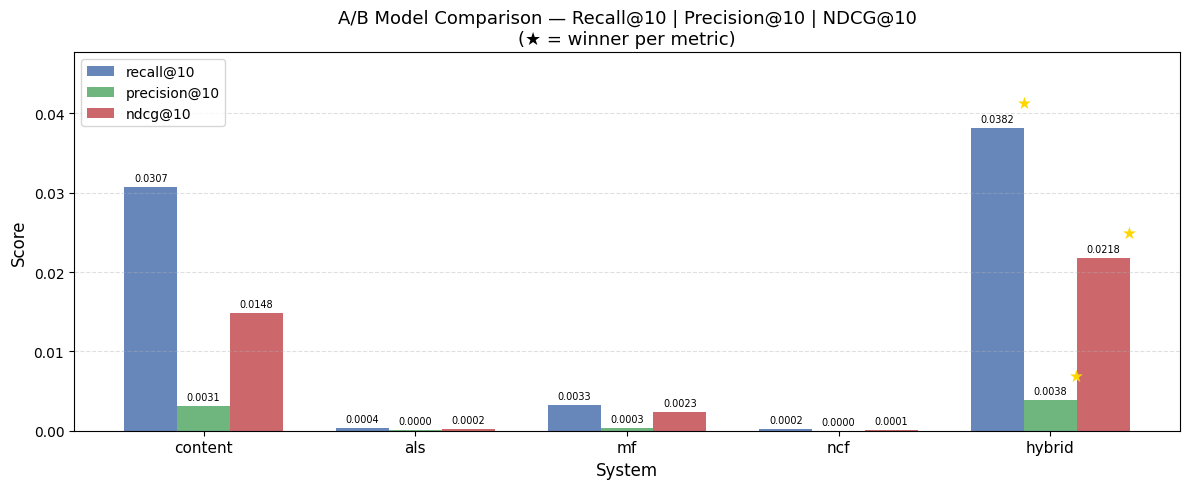

Chart saved to outputs/ab_comparison_chart.png


In [17]:
# ── Grouped bar chart with winner annotation ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(results_df))
width  = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + idx * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=7
        )

# Annotate winner per metric with star
for idx, metric in enumerate(metrics):
    winner_row = results_df[metric].idxmax()
    bar_x      = winner_row + idx * width
    bar_h      = results_df.loc[winner_row, metric]
    ax.text(
        bar_x + width / 2,
        bar_h + 0.002,
        '★',
        ha='center', va='bottom', fontsize=12, color='gold'
    )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['system'], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('System', fontsize=12)
ax.set_title(
    'A/B Model Comparison — Recall@10 | Precision@10 | NDCG@10\n(★ = winner per metric)',
    fontsize=13
)
ax.legend(fontsize=10)
ax.set_ylim(0, max(results_df[metrics].values.max() * 1.25, 0.01))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/ab_comparison_chart.png', dpi=150)
plt.show()
print('Chart saved to outputs/ab_comparison_chart.png')

## Section 9 — Export

In [18]:
results_df.to_csv('outputs/ab_comparison_results.csv', index=False)
print('Saved: outputs/ab_comparison_results.csv')

cold_results_df.to_csv('outputs/cold_start_delta.csv', index=False)
print('Saved: outputs/cold_start_delta.csv')

print('\nPhase 10 complete.')
results_df

Saved: outputs/ab_comparison_results.csv
Saved: outputs/cold_start_delta.csv

Phase 10 complete.


,system,recall@10,precision@10,ndcg@10
0,content,0.030710,0.003071,0.014805
1,als,0.000398,0.000040,0.000221
2,mf,0.003262,0.000326,0.002344
3,ncf,0.000159,0.000016,0.000065
4,hybrid,0.038189,0.003819,0.021751
